=== 期待値 E[x] の比較 ===
近似真値       : 0.9250
単純サンプリング: 0.8915
重要度サンプリング: 0.9196
MCMC           : 0.8881
MCMC 受理率    : 0.6326


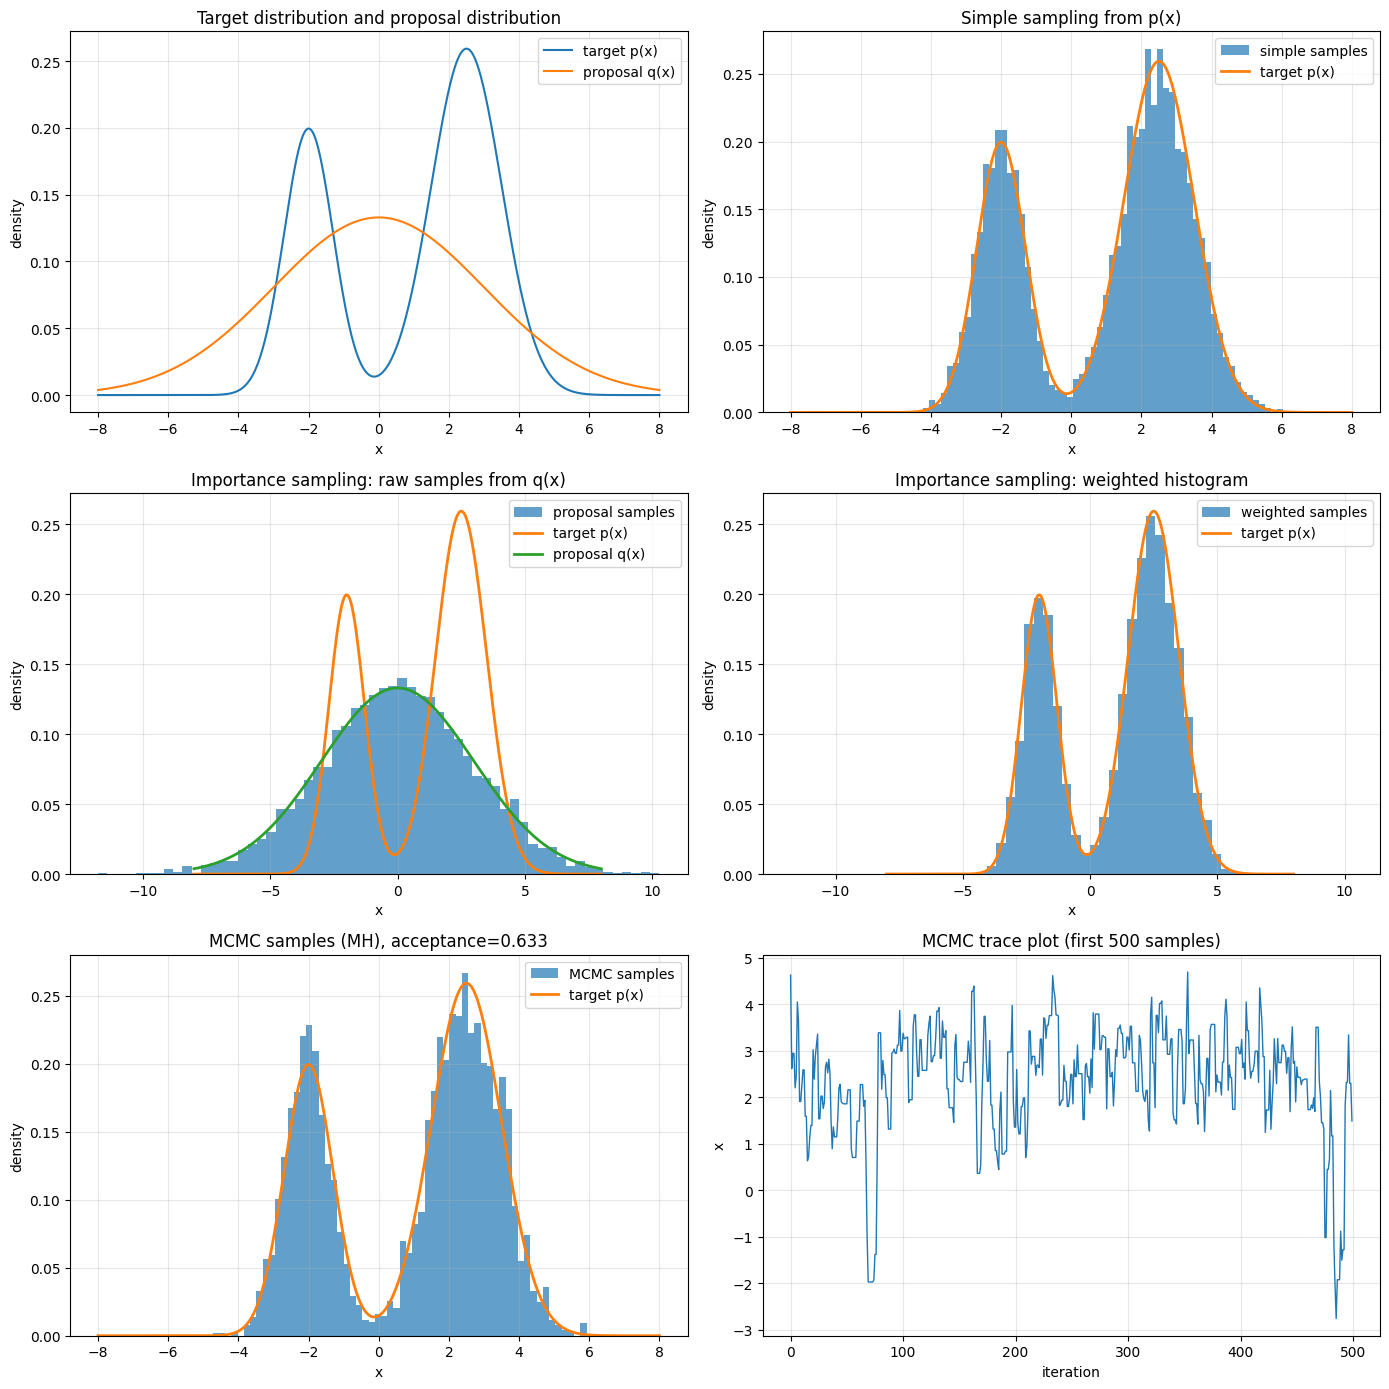

In [1]:
# -*- coding: utf-8 -*-
"""
単純サンプリング・重要度サンプリング・MCMC の比較プロット
- 目的分布: 1次元の混合正規分布
- 単純サンプリング: 目的分布から直接サンプル
- 重要度サンプリング: 提案分布 q(x) からサンプルして重み付け
- MCMC: Metropolis-Hastings でサンプル

出力:
1. 目的分布と提案分布
2. 単純サンプリングのヒストグラム
3. 重要度サンプリングのヒストグラム（重みなし）
4. 重要度サンプリングの重み付きヒストグラム
5. MCMC のヒストグラム
6. MCMC の軌跡（trace plot）
"""

import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 乱数固定
# =========================================================
np.random.seed(42)

# =========================================================
# 目的分布 p(x): 混合正規分布
# =========================================================
def normal_pdf(x, mu, sigma):
    return (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def target_pdf(x):
    # 0.35 * N(-2, 0.7^2) + 0.65 * N(2.5, 1.0^2)
    return 0.35 * normal_pdf(x, -2.0, 0.7) + 0.65 * normal_pdf(x, 2.5, 1.0)

def sample_from_target(n):
    # 混合分布から直接サンプリング
    z = np.random.rand(n)
    samples = np.empty(n)
    left = z < 0.35
    right = ~left
    samples[left] = np.random.normal(loc=-2.0, scale=0.7, size=left.sum())
    samples[right] = np.random.normal(loc=2.5, scale=1.0, size=right.sum())
    return samples

# =========================================================
# 提案分布 q(x): 1つの正規分布
# =========================================================
Q_MU = 0.0
Q_SIGMA = 3.0

def proposal_pdf(x):
    return normal_pdf(x, Q_MU, Q_SIGMA)

def sample_from_proposal(n):
    return np.random.normal(loc=Q_MU, scale=Q_SIGMA, size=n)

# =========================================================
# Metropolis-Hastings
# =========================================================
def metropolis_hastings(n_samples, burn_in=1000, step_size=1.2, x0=0.0):
    samples = np.zeros(n_samples + burn_in)
    x = x0

    accepted = 0

    for i in range(n_samples + burn_in):
        x_prop = np.random.normal(loc=x, scale=step_size)

        p_current = target_pdf(x)
        p_prop = target_pdf(x_prop)

        alpha = min(1.0, p_prop / p_current)

        if np.random.rand() < alpha:
            x = x_prop
            accepted += 1

        samples[i] = x

    kept = samples[burn_in:]
    acc_rate = accepted / (n_samples + burn_in)
    return kept, acc_rate

# =========================================================
# 設定
# =========================================================
N = 5000
GRID_MIN = -8
GRID_MAX = 8
NBINS = 60

x_grid = np.linspace(GRID_MIN, GRID_MAX, 1000)
p_grid = target_pdf(x_grid)
q_grid = proposal_pdf(x_grid)

# =========================================================
# 1. 単純サンプリング
# =========================================================
simple_samples = sample_from_target(N)

# =========================================================
# 2. 重要度サンプリング
# =========================================================
is_samples = sample_from_proposal(N)
weights = target_pdf(is_samples) / proposal_pdf(is_samples)

# 正規化重み
weights_norm = weights / np.sum(weights)

# =========================================================
# 3. MCMC
# =========================================================
mcmc_samples, acc_rate = metropolis_hastings(
    n_samples=N,
    burn_in=1500,
    step_size=1.2,
    x0=0.0
)

# =========================================================
# 参考: 期待値推定
# =========================================================
# 比較用に f(x)=x とする
true_mean_approx = np.trapz(x_grid * p_grid, x_grid) / np.trapz(p_grid, x_grid)
simple_mean = np.mean(simple_samples)
is_mean = np.sum(is_samples * weights_norm)
mcmc_mean = np.mean(mcmc_samples)

print("=== 期待値 E[x] の比較 ===")
print(f"近似真値       : {true_mean_approx:.4f}")
print(f"単純サンプリング: {simple_mean:.4f}")
print(f"重要度サンプリング: {is_mean:.4f}")
print(f"MCMC           : {mcmc_mean:.4f}")
print(f"MCMC 受理率    : {acc_rate:.4f}")

# =========================================================
# プロット
# =========================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.ravel()

# ---------------------------------
# (1) 目的分布と提案分布
# ---------------------------------
ax = axes[0]
ax.plot(x_grid, p_grid, label="target p(x)")
ax.plot(x_grid, q_grid, label="proposal q(x)")
ax.set_title("Target distribution and proposal distribution")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend()
ax.grid(True, alpha=0.3)

# ---------------------------------
# (2) 単純サンプリング
# ---------------------------------
ax = axes[1]
ax.hist(simple_samples, bins=NBINS, density=True, alpha=0.7, label="simple samples")
ax.plot(x_grid, p_grid, linewidth=2, label="target p(x)")
ax.set_title("Simple sampling from p(x)")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend()
ax.grid(True, alpha=0.3)

# ---------------------------------
# (3) 重要度サンプリング（重みなし）
# ---------------------------------
ax = axes[2]
ax.hist(is_samples, bins=NBINS, density=True, alpha=0.7, label="proposal samples")
ax.plot(x_grid, p_grid, linewidth=2, label="target p(x)")
ax.plot(x_grid, q_grid, linewidth=2, label="proposal q(x)")
ax.set_title("Importance sampling: raw samples from q(x)")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend()
ax.grid(True, alpha=0.3)

# ---------------------------------
# (4) 重要度サンプリング（重み付き）
# ---------------------------------
ax = axes[3]
ax.hist(is_samples, bins=NBINS, density=True, weights=weights, alpha=0.7, label="weighted samples")
ax.plot(x_grid, p_grid, linewidth=2, label="target p(x)")
ax.set_title("Importance sampling: weighted histogram")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend()
ax.grid(True, alpha=0.3)

# ---------------------------------
# (5) MCMC のヒストグラム
# ---------------------------------
ax = axes[4]
ax.hist(mcmc_samples, bins=NBINS, density=True, alpha=0.7, label="MCMC samples")
ax.plot(x_grid, p_grid, linewidth=2, label="target p(x)")
ax.set_title(f"MCMC samples (MH), acceptance={acc_rate:.3f}")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend()
ax.grid(True, alpha=0.3)

# ---------------------------------
# (6) MCMC の軌跡
# ---------------------------------
ax = axes[5]
ax.plot(mcmc_samples[:500], linewidth=1)
ax.set_title("MCMC trace plot (first 500 samples)")
ax.set_xlabel("iteration")
ax.set_ylabel("x")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()